# Shuffle analysis of directionality
Originally, this was performed in 2p-py: Directionality analysis.ipynb, in the section "StD of SD1, SD2, Sz angles compared to StD of same number of random angles (radians)"

In [9]:
import sys
import os
import pandas as pd
notebook_dir = os.getcwd()
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..')))  # Add the project root directory to the path
import custom_io as cio
import env_reader
import data_documentation
from directionality_analysis import stdOfUniformAngles, circularStdOfUniformAngles
import matplotlib.pyplot as plt
import h5py
import numpy as np
import scipy.io
from math import pi
from scipy.stats import circstd
import seaborn as sns
import json

In [2]:
save_fig = True

In [3]:
er = env_reader.read_env()

In [4]:
dd = data_documentation.DataDocumentation.from_env_dict(er)

In [13]:
fpath_std_data = cio.open_file("Choose json file with surrogate and measured data (e.g. angles_std_and_surrogate_20240806-152928.json)")
fpath_surrogate_data = cio.open_file("Choose excel file with surrogate and measured data (e.g. surrogate_20250425_pandas.xlsx)")
assert fpath_std_data.endswith('.json'), "Please select a json file with surrogate and measured data"
assert fpath_surrogate_data.endswith('.xlsx'), "Please select a json file with surrogate and measured data"

In [15]:
with open(fpath_std_data, 'r') as f:
    dict_std_data = json.load(f)
df_surrogate = pd.read_excel(fpath_surrogate_data)

In [7]:
df_std = pd.DataFrame(dict_std_data)

In [17]:
df_surrogate

,mouse_id,angle_type,sample
0,T301,sd1,6.633038
1,T301,sd1,8.949342
2,T301,sd1,15.300964
3,T301,sd1,15.363197
4,T301,sd1,16.262126
...,...,...,...
8995,T352,sz,147.283081
8996,T352,sz,148.968096
8997,T352,sz,150.584166
8998,T352,sz,151.547889


In [8]:
df_std

,mouse_id,angle_type,measured_std,n_measurements,simulated_std_threshold_onetailed,p,alpha,n_simulations
0,T301,SD1,14.419881,4,35.975201,0.002,0.05,1000
1,T301,SD2,22.412156,4,34.108263,0.017,0.05,1000
2,T301,Sz,21.601742,3,24.703995,0.035,0.05,1000
3,T329,SD1,63.694857,2,4.656523,0.598,0.05,1000
4,T329,SD2,4.142394,2,4.660960,0.046,0.05,1000
5,T329,Sz,10.047182,2,4.774203,0.102,0.05,1000
6,T333,SD1,55.174162,3,21.517514,0.297,0.05,1000
7,T333,SD2,40.711529,3,18.492062,0.186,0.05,1000
8,T333,Sz,15.191958,3,20.305788,0.024,0.05,1000
9,T352,SD1,16.285584,4,34.594135,0.005,0.05,1000


In [ ]:
df_std["color"] = df_std["mouse_id"].apply(lambda x: dd.get_color_for_mouse_id(x))

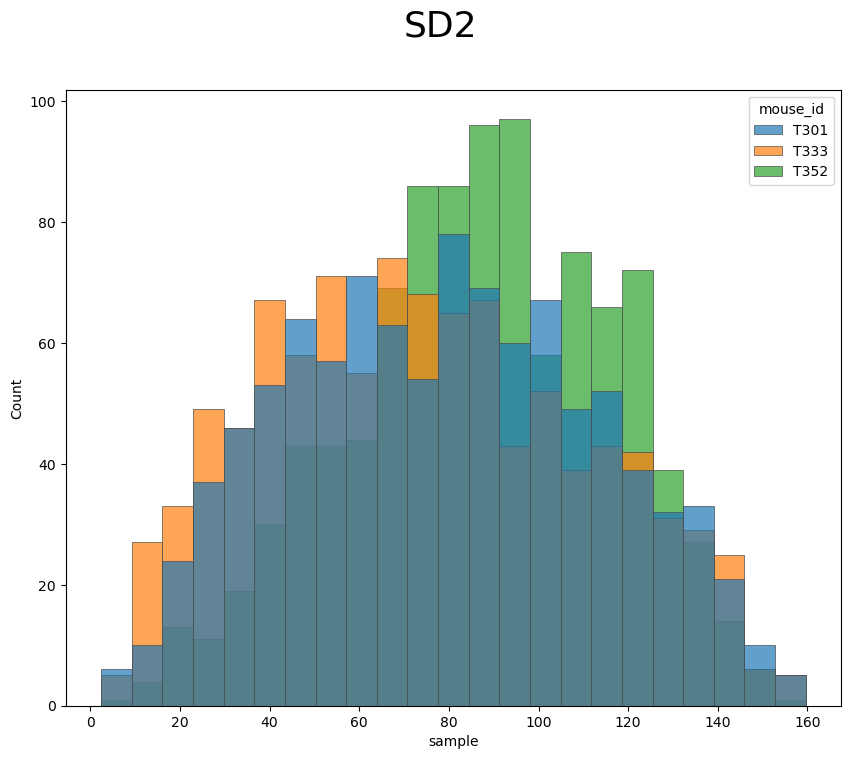

In [19]:
fig, ax = plt.subplots(figsize=(10,8))
plt.suptitle("SD2", fontsize=26)

sns.histplot(
    df_surrogate[df_surrogate["angle_type"] == "sz"],
    x="sample", hue="mouse_id",
    multiple="layer",
    edgecolor=".3",
    linewidth=.5,
    kde=False,
    log_scale=False,
    alpha=0.7,
    ax=ax
)
plt.show()

In [ ]:
mouse_ids = df_std["mouse_id"].unique()
angle_types = df_std["angle_type"].unique()
n_mice = len(mouse_ids)
n_angle_types = len(angle_types)

fig, axs = plt.subplots(n_mice, n_angle_types, figsize=(n_mice*8, n_angle_types*8))
for i_mouse, mouse_id in enumerate(mouse_ids):
    for i_event, angle_type in enumerate(angle_types):
        color = df_std[(df_std["mouse_id"] == mouse_id) & (df_std["angle_type"] == angle_type)]["color"].iloc[0]
        ax = axs[i_mouse][i_event]
        surrogate_data = dict_surrogate_data[mouse_id][angle_type]
        ax.hist(surrogate_data, bins=30, alpha=0.5, color=color)
        ax.axvline(x=df_std[(df_std["mouse_id"] == mouse_id) & (df_std["angle_type"] == angle_type)]["measured_std"].iloc[0], color=color, linestyle='--', label="angle stdev.")
        ax.axvline(x=np.percentile(surrogate_data, 5), color='red', linestyle='--', label="5% percentile")
        ax.set_title(f"Standard deviation of angles for {angle_type}, {mouse_id}", fontsize=20)
        ax.set_xlabel("Standard deviation (°)", fontsize=16)
        ax.legend()

if save_fig:
    fig.savefig(os.path.join(er["OUTPUT_FOLDER"], "all_events_surrogate_tests.pdf"))
plt.show()

In [ ]:
dict_matlab_export = {}
for mouse_id in dict_surrogate_data.keys():
    if mouse_id not in dict_std_data:
        dict_matlab_export[mouse_id] = {}
    for angle_type in dict_surrogate_data[mouse_id].keys():
        if angle_type not in dict_matlab_export[mouse_id]:
            dict_matlab_export[mouse_id][angle_type] = {}
        dict_matlab_export[mouse_id][angle_type]["surrogate"] = np.array(dict_surrogate_data[mouse_id][angle_type])

for i in range(len(dict_std_data["mouse_id"])):
    mouse_id = dict_std_data["mouse_id"][i]
    angle_type = dict_std_data["angle_type"][i]
    measured_std = dict_std_data["measured_std"][i]
    n_measurements = dict_std_data["n_measurements"][i]
    surrogate_std_threshold_onetailed = dict_std_data["simulated_std_threshold_onetailed"][i]
    p = dict_std_data["p"][i]
    alpha = dict_std_data["alpha"][i]
    surrogate_size = dict_std_data["n_simulations"][i]

    dict_matlab_export[mouse_id][angle_type]["measured_std"] = measured_std
    dict_matlab_export[mouse_id][angle_type]["n_measurements"] = n_measurements
    dict_matlab_export[mouse_id][angle_type]["std_threshold_onetailed"] = surrogate_std_threshold_onetailed
    dict_matlab_export[mouse_id][angle_type]["p"] = p
    dict_matlab_export[mouse_id][angle_type]["alpha"] = alpha
    dict_matlab_export[mouse_id][angle_type]["surrogate_size"] = surrogate_size



In [ ]:
# Save the dictionary to a .mat file
matlab_file_path = os.path.join(er["OUTPUT_FOLDER"], "all_events_surrogate_tests.mat")
scipy.io.savemat(matlab_file_path, dict_matlab_export)